# Semana 8 aplicada a diabetes · GMM, KDE y DBSCAN como tres fuentes de evidencia

**Datos:** `diabetic_data.csv` (130 hospitales de EE. UU., 1999–2008). **Guía:** `semana-08.html` y cuadernos
`sesion_1_gmm`, `sesion_2_kde`, `sesion_3_dbscan`, `refuerzo_kmeans`, `refuerzo_jerarquico`.

**Adaptación del problema.** En el caso original el comité de movilidad busca *zonas del mapa* para un estudio operativo.
Aquí no hay mapa: el "espacio" es un plano de **perfil clínico de hospitalización** construido con las variables
numéricas del encuentro. El comité (ahora de gestión hospitalaria) desea explorar **perfiles de pacientes candidatos
para un estudio de seguimiento post-alta**. No dispone de costos, capacidad de seguimiento ni desenlaces tras el alta.

> Propongan **dos zonas (perfiles) para estudiar y un perfil para revisar**, o expliquen por qué los datos no bastan.
> Usen GMM, KDE y DBSCAN como tres fuentes de evidencia. No interpreten un centroide como un "paciente tipo" óptimo.

Así como densidad de recogidas no es demanda, **densidad de pacientes no es riesgo**: la tasa de readmisión se usa
solo *después* de congelar los modelos, como descripción externa de las zonas, nunca para ajustarlos.

In [1]:
import warnings; warnings.filterwarnings("ignore")
import time
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from IPython.display import display
from scipy.special import logsumexp
from scipy.stats import norm
from scipy.integrate import trapezoid
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture
from sklearn.neighbors import KernelDensity, NearestNeighbors
from sklearn.cluster import DBSCAN, KMeans
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import silhouette_score

SEED = 42
COLORS = ['#087f8c', '#d57927', '#7856a5', '#c94d61', '#418650', '#b49b24', '#547ba5', '#7a5342']
plt.rcParams.update({'figure.dpi': 110, 'font.size': 10, 'axes.spines.top': False, 'axes.spines.right': False,
                     'axes.titleweight': 'bold', 'axes.prop_cycle': plt.cycler(color=COLORS)})

# Utilidades equivalentes a movilidad.py, adaptadas a un plano en desviaciones estándar.
def plane_axes(ax, title):
    ax.set(title=title, xlabel='CP1 · intensidad de la hospitalización (d.e.)', ylabel='CP2 · uso previo de servicios (d.e.)')
    ax.set_aspect('equal', adjustable='box'); ax.set_xlim(*XLIM); ax.set_ylim(*YLIM)

def ellipses(ax, model):
    for k, mean in enumerate(model.means_):
        cov = model.covariances_[k]
        if model.covariance_type == 'diag': cov = np.diag(cov)
        vals, vecs = np.linalg.eigh(cov)
        angle = np.degrees(np.arctan2(vecs[1, -1], vecs[0, -1]))
        ax.add_patch(Ellipse(mean, 2*np.sqrt(5.991*vals[-1]), 2*np.sqrt(5.991*vals[0]), angle=angle,
                             facecolor='none', edgecolor=COLORS[k % 8], lw=2))

# Silhouette es O(n²): se calcula sobre una submuestra FIJA (semilla 42) de a lo sumo 1 000 puntos no-ruido.
# Todas las silhouettes del cuaderno son, por tanto, estimaciones sobre 1 000 puntos, no sobre los 6 000.
def safe_silhouette(X, labels, cap=1000):
    labels = np.asarray(labels); mask = labels != -1
    x, lab = X[mask], labels[mask]
    if len(x) < 3 or not 2 <= len(np.unique(lab)) < len(x): return np.nan
    ids = np.random.default_rng(SEED).choice(len(x), min(cap, len(x)), replace=False)
    if not 2 <= len(np.unique(lab[ids])) < len(ids): return np.nan
    return silhouette_score(x[ids], lab[ids])

def grid(size=160):
    gx, gy = np.linspace(*XLIM, size), np.linspace(*YLIM, size)
    xx, yy = np.meshgrid(gx, gy); return gx, gy, xx, yy, np.c_[xx.ravel(), yy.ravel()]

## 0. Contrato experimental (se completa antes de elegir modelos)

| Decisión | Acuerdo |
|---|---|
| **Unidad de análisis y población observada** | Un encuentro hospitalario: el **primer ingreso registrado de cada paciente**. Aquí la pregunta es *cómo se distribuyen los pacientes*, así que la unidad es el paciente: conservar todos sus encuentros haría pesar más a quienes se hospitalizan con frecuencia y deformaría la densidad. (En el cuaderno de clasificación, donde la unidad es el encuentro, sí se conservan todos y se valida con `StratifiedGroupKFold` por paciente.) Observamos solo pacientes diabéticos *hospitalizados* 1–14 días en 130 hospitales que reportan a esta base; no representa a todos los diabéticos ni a la atención ambulatoria. |
| **Dos variables del plano y sus unidades** | CP1 y CP2 del análisis de componentes principales sobre 9 variables numéricas transformadas con `log1p` y estandarizadas **con desarrollo**. Ambos ejes están en **desviaciones estándar** (d.e.), la misma unidad, así que la distancia euclídea es comparable en los dos ejes (análogo a proyectar a km en lugar de usar grados). |
| **Periodo de selección y periodo reservado** | No hay fecha; `encounter_id` es cronológico. **Desarrollo:** primer 70 % de pacientes en orden de `encounter_id` (muestra de 6 000, semilla 42). **Test reservado:** último 30 %. Toda elección (K, h, eps) se hace con desarrollo; el test se abre una sola vez al final. |
| **Limpieza vs. recorte** | *Limpieza* = quitar registros no válidos para la pregunta: género inválido, pacientes fallecidos o en hospicio (no pueden recibir seguimiento), encuentros repetidos del mismo paciente. *Recorte* = limitar el plano a una región; **no recortamos**: los valores extremos (p. ej. 20+ visitas previas) son pacientes reales, no errores. Los límites de las figuras son solo de visualización. |
| **Qué sería una recomendación útil** | Rangos del plano (y su traducción a variables clínicas) que definan grupos de pacientes suficientemente numerosos y estables en el periodo reservado como para diseñar un estudio de seguimiento. |
| **Qué falta para operar** | Costo y capacidad del seguimiento, desenlaces tras el alta, factores sociales, efecto causal de una intervención. La readmisión observada es una etiqueta incompleta (solo readmisiones en la misma red). |

## 1. ¿Qué hay detrás del plano? Auditoría y representación
La auditoría aplica reglas **secuenciales**: cada fila del original cae en exactamente un motivo y los motivos suman el total.

In [2]:
raw = pd.read_csv('diabetic_data.csv', na_values=['?'], keep_default_na=False)
dead_or_hospice = [11, 13, 14, 19, 20, 21]
raw = raw.sort_values('encounter_id').reset_index(drop=True)
motivo = np.select(
    [raw.gender.eq('Unknown/Invalid'),
     raw.discharge_disposition_id.isin(dead_or_hospice),
     raw.duplicated('patient_nbr', keep='first')],
    ['genero_invalido', 'fallecido_u_hospicio', 'encuentro_repetido_del_paciente'], default='apto')
# Un paciente cuyo primer encuentro se excluyó no debe reaparecer con un encuentro posterior.
first_seen = ~raw.duplicated('patient_nbr', keep='first')
auditoria = pd.Series(motivo).value_counts().rename_axis('motivo').reset_index(name='n')
auditoria['porcentaje'] = (100 * auditoria.n / len(raw)).round(3)
display(auditoria); assert auditoria.n.sum() == len(raw)

data = raw[motivo == 'apto'].copy()
data['age_num'] = data.age.str.extract(r'\[(\d+)-').astype(int)[0] + 5
data['readm30'] = (data.readmitted == '<30').astype(int)
FEATURES = ['time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications',
            'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses', 'age_num']

cut = int(len(data) * 0.7)
dev_pool, test = data.iloc[:cut], data.iloc[cut:].copy()
dev = dev_pool.sample(6000, random_state=SEED).sort_values('encounter_id').copy()
assert dev.encounter_id.max() < test.encounter_id.min()
print(f'Aptos: {len(data):,} | pool de desarrollo: {len(dev_pool):,} | muestra de desarrollo: {len(dev):,} | test reservado: {len(test):,}')

,motivo,n,porcentaje
0,apto,69970,68.756
1,encuentro_repetido_del_paciente,29370,28.860
2,fallecido_u_hospicio,2423,2.381
3,genero_invalido,3,0.003


Aptos: 69,970 | pool de desarrollo: 48,979 | muestra de desarrollo: 6,000 | test reservado: 20,991


**Representación.** Las variables son conteos con colas largas y escalas distintas (días, procedimientos, medicamentos, años).
Si se usaran tal cual, la distancia la dominaría `num_lab_procedures` (rango 1–132). Por eso: `log1p` → estandarización
**ajustada solo con desarrollo** → PCA a 2 componentes. El escalado aquí sí es necesario (a diferencia de las coordenadas
UTM del caso original, aquí las variables no comparten unidad); lo que evitamos es escalar cada eje del plano final por separado.

Varianza explicada: [0.229 0.144] → total 0.373


,CP1,CP2
time_in_hospital,0.500000,-0.150000
num_lab_procedures,0.250000,-0.110000
num_procedures,0.360000,-0.280000
num_medications,0.550000,-0.120000
number_outpatient,0.090000,0.540000
number_emergency,0.060000,0.520000
number_inpatient,0.150000,0.480000
number_diagnoses,0.410000,0.220000
age_num,0.230000,0.150000


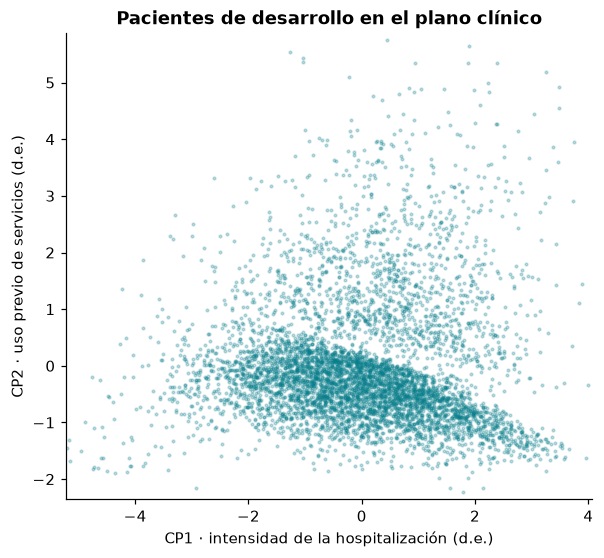

Puntos repetidos exactamente en el plano: 13


In [3]:
scaler = StandardScaler().fit(np.log1p(dev[FEATURES]))
pca = PCA(2, random_state=SEED).fit(scaler.transform(np.log1p(dev[FEATURES])))
if pca.components_[0][FEATURES.index('num_medications')] < 0: pca.components_[0] *= -1
if pca.components_[1][FEATURES.index('number_inpatient')] < 0: pca.components_[1] *= -1
project = lambda f: pca.transform(scaler.transform(np.log1p(f[FEATURES])))
X, Xt = project(dev), project(test)
dev[['cp1', 'cp2']], test[['cp1', 'cp2']] = X, Xt
XLIM = (np.percentile(X[:, 0], .2) - .5, np.percentile(X[:, 0], 99.8) + .5)
YLIM = (np.percentile(X[:, 1], .2) - .5, np.percentile(X[:, 1], 99.8) + .5)

loadings = pd.DataFrame(pca.components_.T, index=FEATURES, columns=['CP1', 'CP2']).round(2)
print('Varianza explicada:', pca.explained_variance_ratio_.round(3), '→ total', pca.explained_variance_ratio_.sum().round(3))
display(loadings.style.background_gradient(cmap='RdBu_r', vmin=-.7, vmax=.7))

fig, ax = plt.subplots(figsize=(8, 5.5))
ax.scatter(*X.T, s=3, alpha=.25, color=COLORS[0]); plane_axes(ax, 'Pacientes de desarrollo en el plano clínico')
plt.show()
print('Puntos repetidos exactamente en el plano:', len(X) - len(np.unique(X.round(8), axis=0)))

### Para resolver
Antes de ajustar: ¿cuántos grupos ves? ¿Qué podría significar un punto aislado?

**Nuestra respuesta y evidencia:**


- **Qué se ve:** una masa densa y alargada en la parte baja del plano (CP2 ≈ −1.5 a 0.5 d.e.), que se extiende a lo largo de CP1, y un
  **abanico disperso hacia arriba** (CP2 > 1 d.e.). Según las cargas, CP1 crece con estancia, medicamentos, procedimientos y diagnósticos
  (intensidad del ingreso) y CP2 con visitas ambulatorias, de urgencias y hospitalizaciones previas (uso previo de servicios).
  Los dos ejes explican el 37 % de la varianza de las 9 variables: el plano es un resumen, no toda la información.
- **Dos particiones plausibles:** (a) "sin uso previo" (masa baja) vs. "con uso previo" (abanico); (b) dividir además la masa baja
  en ingresos cortos/simples (CP1 < 0) e ingresos largos/complejos (CP1 > 0).
- **Un punto aislado** es un paciente con una combinación rara (p. ej. 6 hospitalizaciones y 6 urgencias previas). Puede ser
  legítimo y clínicamente importante; aislado no significa error de captura.
- **Limitación:** las variables son conteos, por eso aparecen bandas y 13 puntos repetidos exactamente; la geometría no es continua.

## 2. GMM · De Bayes a EM (Sesión 1)
$$r_{ik}=\frac{\pi_k\phi(x_i;\mu_k,\Sigma_k)}{\sum_j\pi_j\phi(x_i;\mu_j,\Sigma_j)},\quad N_k=\sum_i r_{ik},\quad
\pi_k^{+}=\frac{N_k}{n},\quad \mu_k^{+}=\frac{\sum_i r_{ik}x_i}{N_k},\quad \Sigma_k^{+}=\frac{\sum_i r_{ik}(x_i-\mu_k^{+})(x_i-\mu_k^{+})^T}{N_k}.$$

### Para resolver (iteración manual)
$x=(-2,-1,1,2)$, pesos $(0.5,0.5)$, medias $(-1,1)$, varianzas $(1,1)$.

In [4]:
x = np.array([-2., -1., 1., 2.])
weights, means, variances = np.array([.5, .5]), np.array([-1., 1.]), np.ones(2)
history, first = [], None
for it in range(12):
    log_joint = np.log(weights)[None, :] + norm.logpdf(x[:, None], means, np.sqrt(variances))
    history.append(float(logsumexp(log_joint, axis=1).sum()))
    resp = np.exp(log_joint - logsumexp(log_joint, axis=1, keepdims=True))
    nk = resp.sum(0); weights = nk / len(x)
    means = (resp * x[:, None]).sum(0) / nk
    variances = (resp * (x[:, None] - means) ** 2).sum(0) / nk
    if it == 0: first = (resp.round(4), weights.round(4), means.round(4), variances.round(4))
assert np.all(np.diff(history) >= -1e-9)
for name, v in zip(['responsabilidades (filas = x)', 'pesos', 'medias', 'varianzas'], first): print(name, '\n', v)
print('log-verosimilitud por iteración:', np.round(history[:5], 4), '...')

responsabilidades (filas = x) 
 [[0.982  0.018 ]
 [0.8808 0.1192]
 [0.1192 0.8808]
 [0.018  0.982 ]]
pesos 
 [0.5 0.5]
medias 
 [-1.3448  1.3448]
varianzas 
 [0.6914 0.6914]
log-verosimilitud por iteración: [-7.1582 -6.4619 -5.7243 -5.6757 -5.6757] ...


**Nuestra respuesta y evidencia:**


**E-step:** para $x=-2$: $r_{1}=\frac{e^{-0.5}}{e^{-0.5}+e^{-4.5}}=\frac{1}{1+e^{-4}}=0.982$; para $x=-1$: $\frac{1}{1+e^{-2}}=0.881$;
por simetría $x=1\to0.119$ y $x=2\to0.018$.
**M-step:** $N_1=N_2=2.0$ → pesos $(0.5,0.5)$; $\mu_1=\frac{-2(0.982)-1(0.881)+1(0.119)+2(0.018)}{2}=-1.345$, $\mu_2=1.345$;
$\sigma_1^2=\sigma_2^2=0.691$ (calculada con la **media nueva**). La log-verosimilitud sube de −7.158 a −6.462 y se estabiliza en −5.676:
EM mejora localmente; las medias se separan y las varianzas se reducen porque los datos están más alejados que las medias iniciales.

### 2.1 Elegir complejidad sin abrir test
$\mathrm{BIC}=-2\ell(\hat\theta)+p\log n$. Para covarianza completa $p=(K-1)+Kd+Kd(d+1)/2$. Se compara BIC solo sobre las mismas 6 000 observaciones.

,k,covariance,bic,aic,converged,iterations
4,5,full,36143.0,35948.7,True,21
5,6,full,36168.7,35934.3,True,20
6,7,full,36212.2,35937.5,True,17
8,9,full,36225.9,35870.8,True,16
7,8,full,36240.1,35925.2,True,17
3,4,full,36253.9,36099.8,True,20
9,10,full,36343.8,35948.6,True,12
18,9,diag,36447.1,36152.3,True,12


Ganador BIC: {'k': 5, 'covariance': 'full'}


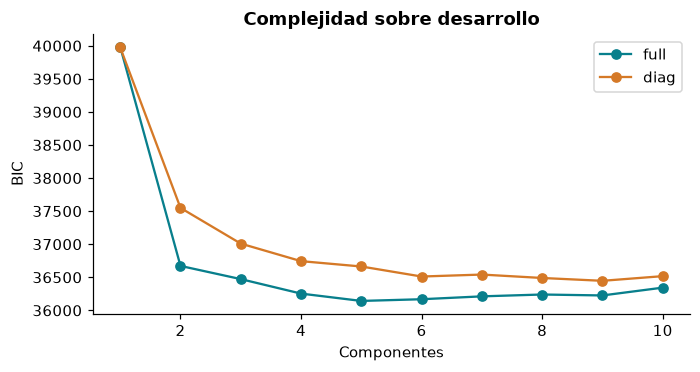

In [5]:
models, rows = {}, []
for cov in ['full', 'diag']:
    for k in range(1, 11):
        m = GaussianMixture(k, covariance_type=cov, n_init=5, max_iter=400, reg_covar=1e-5, random_state=SEED).fit(X)
        rows.append(dict(k=k, covariance=cov, bic=m.bic(X), aic=m.aic(X), converged=bool(m.converged_), iterations=m.n_iter_))
        models[(k, cov)] = m
gmm_sel = pd.DataFrame(rows)
display(gmm_sel.sort_values('bic').head(8).round(1))
winner = gmm_sel[gmm_sel.converged].sort_values('bic').iloc[0]
best = models[(int(winner.k), winner.covariance)]
print('Ganador BIC:', dict(k=int(winner.k), covariance=winner.covariance))
fig, ax = plt.subplots(figsize=(7, 3.3))
for cov in ['full', 'diag']:
    part = gmm_sel[gmm_sel.covariance == cov]; ax.plot(part.k, part.bic, 'o-', label=cov)
ax.set(xlabel='Componentes', ylabel='BIC', title='Complejidad sobre desarrollo'); ax.legend(); plt.show()

### Para resolver
Si el mínimo ocurre en el borde de la rejilla, ¿qué puede concluir? ¿Se justifica anunciar K perfiles verdaderos?

**Nuestra respuesta y evidencia:**


El mínimo está en **K = 5 con covarianza completa**, en el interior de la rejilla 1–10 (no en el borde), y K = 6 queda a solo 26 puntos de BIC.
Con covarianza diagonal el ganador sería K = 9: con elipses alineadas a los ejes se necesitan más piezas para aproximar la misma forma.
**Conclusión posible:** entre los candidatos, 5 gaussianas completas son el mejor compromiso ajuste/complejidad *para aproximar esta densidad*.
**No se justifica** anunciar "5 perfiles verdaderos de pacientes": los datos son conteos asimétricos, no gaussianos, y varias componentes
pueden estar modelando una sola cola alargada. Si el mínimo hubiese caído en el borde, solo diríamos que la rejilla era insuficiente.

### 2.2 Figura 1 · Componentes, contornos del 95 % y entropía de pertenencia

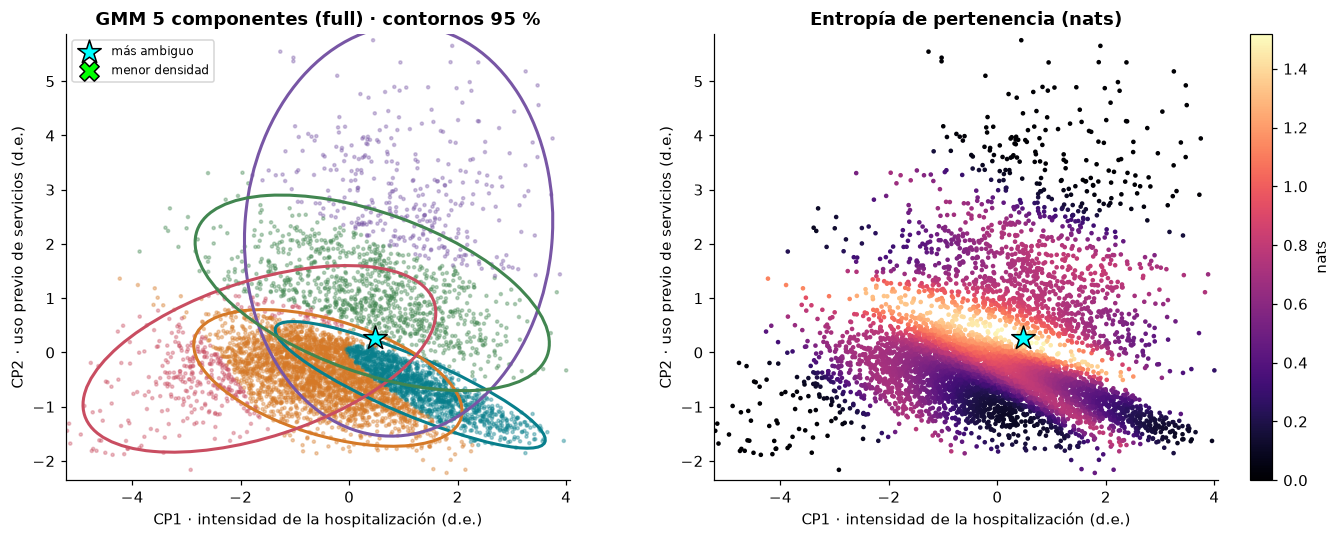

,peso,media_cp1,media_cp2
0,0.221,1.13,-0.60
1,0.423,-0.39,-0.47
2,0.088,0.91,2.24
3,0.133,-1.66,-0.12
4,0.135,0.42,1.10


Proporción asignada (asignación dura): [0.23516667 0.4765     0.06016667 0.063      0.16516667]
Punto más ambiguo:  responsabilidades [0.139 0.303 0.086 0.184 0.287] | log-densidad -3.27 | percentil de densidad 0.359
Punto de menor densidad: máx. responsabilidad 1.0 | log-densidad -16.86


,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses,age_num,cp1,cp2
ambiguo,8,64,0,16,0,0,1,7,35,0.47,0.26
baja densidad,12,79,3,28,3,6,6,9,55,4.29,8.55


In [6]:
resp = best.predict_proba(X)
entropy = -(resp * np.log(np.maximum(resp, 1e-300))).sum(1)
logdens_gmm = best.score_samples(X)
i_amb, i_low = int(np.argmax(entropy)), int(np.argmin(logdens_gmm))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(*X.T, c=np.asarray(COLORS)[best.predict(X) % 8], s=4, alpha=.35); ellipses(axes[0], best)
pts = axes[1].scatter(*X.T, c=entropy, cmap='magma', s=4)
for ax, t in zip(axes, [f'GMM {int(winner.k)} componentes ({winner.covariance}) · contornos 95 %', 'Entropía de pertenencia (nats)']):
    plane_axes(ax, t)
    ax.scatter(*X[i_amb], marker='*', s=260, c='cyan', edgecolor='k', label='más ambiguo')
    ax.scatter(*X[i_low], marker='X', s=160, c='lime', edgecolor='k', label='menor densidad')
axes[0].legend(loc='upper left', fontsize=8); fig.colorbar(pts, ax=axes[1], label='nats'); fig.tight_layout(); plt.show()

comp = pd.DataFrame({'peso': best.weights_.round(3), 'media_cp1': best.means_[:, 0].round(2), 'media_cp2': best.means_[:, 1].round(2)})
display(comp)
print('Proporción asignada (asignación dura):', np.bincount(best.predict(X), minlength=int(winner.k)) / len(X))
cols = FEATURES + ['cp1', 'cp2']
print('Punto más ambiguo:  responsabilidades', resp[i_amb].round(3), '| log-densidad', logdens_gmm[i_amb].round(2),
      '| percentil de densidad', (logdens_gmm < logdens_gmm[i_amb]).mean().round(3))
print('Punto de menor densidad: máx. responsabilidad', resp[i_low].max().round(3), '| log-densidad', logdens_gmm[i_low].round(2))
display(dev.iloc[[i_amb, i_low]][cols].set_axis(['ambiguo', 'baja densidad']).round(2))

### Para resolver
Elijan un punto de pertenencia ambigua y otro de densidad baja. ¿Son necesariamente el mismo?

**Nuestra respuesta y evidencia:**


- **Punto ambiguo** (estrella; CP1 = 0.47, CP2 = 0.26): responsabilidades (0.14, 0.30, 0.09, 0.18, 0.29), ninguna domina.
  Es un paciente de 35 años, 8 días de estancia, 1 hospitalización previa. Su log-densidad (−3.27) está en el **percentil 36**: no es un punto raro,
  está en la zona donde se **superponen** cuatro elipses.
- **Punto de menor densidad** (CP1 = 4.29, CP2 = 8.55, fuera de los límites de la figura): log-densidad −16.9, pero responsabilidad **1.0** para una componente.
  6 hospitalizaciones, 6 urgencias y 3 consultas previas.
- **No son el mismo.** La responsabilidad compara componentes *entre sí* (normaliza por la densidad total); la densidad mide qué tan común es el punto.
  Un punto lejano puede ser raro y a la vez asignado sin ambigüedad a la componente más ancha. Una responsabilidad de 0.55 significaría
  "55 % de la densidad en ese punto proviene de esa componente", no "55 % de probabilidad de pertenecer a un perfil real".

### 2.3 ¿Qué representa cada componente?

**Nuestra respuesta y evidencia:**


Los **pesos** del modelo ($\pi_k$: 0.22, 0.42, 0.09, 0.13, 0.14) y la **proporción asignada** por máxima responsabilidad (0.24, 0.48, 0.06, 0.06, 0.17)
no coinciden: las componentes anchas (2 y 3) tienen más peso que puntos "ganados", porque comparten masa con sus vecinas. Descripción con
medianas de los pacientes asignados (rangos p5–p95 en la tabla de la sección 6.2); la readmisión se calculó después de congelar el modelo:

| Comp. | Asignados | Rango del plano | Perfil clínico (medianas) | Readmisión < 30 d (desarrollo / test) |
|---|---|---|---|---|
| **1** | 48 % | CP1 −2.0 a 0.9; CP2 −1.3 a 0.4 | **Núcleo:** 3 días, 41 análisis, 12 medicamentos, 6 diagnósticos, 65 años, sin visitas previas | 7.8 % / 5.9 % (bajo la base) |
| **0** | 24 % | CP1 0.2 a 2.8; CP2 −1.4 a 0 | **Ingresos largos y complejos sin uso previo:** 6 días, 52 análisis, 2 procedimientos, 19 medicamentos, 9 diagnósticos, 75 años | 12.1 % / 7.6 % (≈ base) |
| **4** | 17 % | CP1 −1.7 a 2.4; CP2 0.1 a 2.2 | **Uso previo moderado:** 4 días, 15 medicamentos, 8 diagnósticos, 75 años; el **100 %** tiene al menos una visita previa (vs. 25.5 % en toda la muestra), pero de un solo tipo: la mediana de cada tipo de visita es 0 | 12.3 % / 7.8 % (≈ base) |
| **3** | 6 % | CP1 −4.5 a −0.8; CP2 −1.6 a 0.8 | **Ingresos breves y simples, pacientes jóvenes:** 2 días, 0 procedimientos, 6 medicamentos, 4 diagnósticos, 45 años | 6.1 % / 5.0 % (la más baja) |
| **2** | 6 % | CP1 −0.8 a 3.0; CP2 1.7 a 5.0 | **Uso previo alto:** 4 días, 16 medicamentos, 9 diagnósticos, 75 años, 1 consulta, 1 urgencia y 1 hospitalización previas (medianas) | 18.3 % / 11.8 % (la más alta, ≈1.6–1.8 × base) |

Las componentes 1 y 3 son las de menor readmisión; 0 y 4 están en torno a la base; solo la 2 se separa claramente. La base es 10.0 % en desarrollo y 7.2 % en test.

## 3. KDE · Del punto a una superficie (Sesión 2)
$\hat f_h(x)=\frac{1}{nh^d}\sum_i K\left(\frac{x-x_i}{h}\right)$. En este plano la densidad está en **d.e.$^{-2}$**; su integral sobre una región es una proporción de pacientes.

### Para resolver
Con $x=(-1,0,1)$ y kernel gaussiano, calcule $\hat f_h(0)$ para $h=0.5,1,2$. ¿Debe decrecer siempre la altura al aumentar h?

In [7]:
for h in [.5, 1, 2]:
    manual = np.mean(norm.pdf((0 - np.array([-1, 0, 1])) / h)) / h
    sk = np.exp(KernelDensity(bandwidth=h).fit(np.array([[-1.], [0.], [1.]])).score_samples([[0.]]))[0]
    print(f'h={h}: f(0) manual={manual:.4f} | sklearn={sk:.4f}')
    assert np.isclose(manual, sk)
# Contraejemplo: en un punto alejado de los datos la altura CRECE con h.
for h in [.5, 1, 2]:
    print(f'h={h}: f(4) = {np.mean(norm.pdf((4 - np.array([-1, 0, 1])) / h)) / h:.5f}')

h=0.5: f(0) manual=0.3379 | sklearn=0.3379
h=1: f(0) manual=0.2943 | sklearn=0.2943
h=2: f(0) manual=0.1838 | sklearn=0.1838
h=0.5: f(4) = 0.00000
h=1: f(4) = 0.00152
h=2: f(4) = 0.03351


**Nuestra respuesta y evidencia:**


$\hat f_h(0)=\frac{1}{3h}\left[\phi(1/h)+\phi(0)+\phi(1/h)\right]$: **0.338** (h = 0.5), **0.294** (h = 1), **0.184** (h = 2) — coinciden con scikit-learn.
En 0 decrece, pero **no siempre**: en $x=4$, lejos de los datos, la altura *crece* con h (0.000 → 0.0015 → 0.034), porque un kernel más
ancho reparte masa hacia las zonas vacías. Aumentar h reduce varianza y aumenta sesgo; no mueve la densidad en una sola dirección.

### 3.1 Elegir h con validación temporal dentro de desarrollo
Tres particiones expansivas en orden de `encounter_id`: cada KDE se ajusta con el pasado del fold y se evalúa en el bloque siguiente
con la **log-densidad media por observación** (comparable entre folds de distinto tamaño).

,h,mean,std
0,0.05,-6.2112,3.1325
1,0.10,-3.7414,0.7250
2,0.20,-3.2044,0.1655
3,0.30,-3.1354,0.0689
4,0.40,-3.1341,0.0379
5,0.60,-3.1842,0.0193
6,0.80,-3.2595,0.0144
7,1.60,-3.6412,0.0129


Ancho congelado (d.e.): 0.4


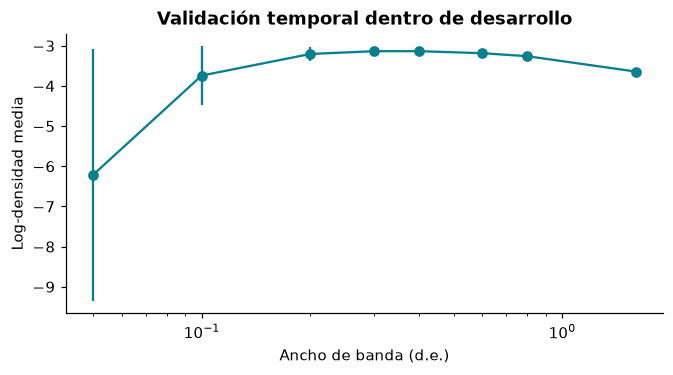

In [8]:
bandwidths = [.05, .1, .2, .3, .4, .6, .8, 1.6]
folds = list(TimeSeriesSplit(n_splits=3).split(X))
rows = []
for h in bandwidths:
    for f, (tr, va) in enumerate(folds, 1):
        assert dev.encounter_id.iloc[tr].max() < dev.encounter_id.iloc[va].min()
        rows.append(dict(h=h, fold=f, mean_log_density=KernelDensity(bandwidth=h).fit(X[tr]).score_samples(X[va]).mean()))
kde_cv = pd.DataFrame(rows).groupby('h').mean_log_density.agg(['mean', 'std']).reset_index()
display(kde_cv.round(4))
best_h = float(kde_cv.loc[kde_cv['mean'].idxmax(), 'h'])
kde = KernelDensity(bandwidth=best_h).fit(X)
print('Ancho congelado (d.e.):', best_h)
fig, ax = plt.subplots(figsize=(7, 3.3))
ax.errorbar(kde_cv.h, kde_cv['mean'], yerr=kde_cv['std'], fmt='o-'); ax.set_xscale('log')
ax.set(xlabel='Ancho de banda (d.e.)', ylabel='Log-densidad media', title='Validación temporal dentro de desarrollo'); plt.show()

### Para resolver
¿Por qué no comparar `score(X)` de modelos con distinto n sin normalizar? ¿Por qué no usar la altura del pico para elegir h?

**Nuestra respuesta y evidencia:**


Se eligió **h = 0.4 d.e.** (log-densidad media −3.134 en validación; h = 0.3 casi empata con −3.135, y h = 0.05 cae a −6.2 con desviación 3.1).
- `score(X)` es una **suma** de log-densidades: crece en valor absoluto con n, así que comparar modelos evaluados sobre bloques de distinto tamaño
  sin dividir por n compara tamaños, no calidad. Por eso usamos la media por observación.
- La **altura del pico** siempre aumenta al reducir h (en el límite, picos de altura infinita sobre cada paciente). Premiarla elige el modelo
  más sobreajustado; lo que importa es qué tan bien predice la densidad de pacientes **futuros** (bloque siguiente en orden de `encounter_id`).

### 3.2 Figura 2 · Superficie KDE con tres anchos (misma escala de color y mismos ejes)

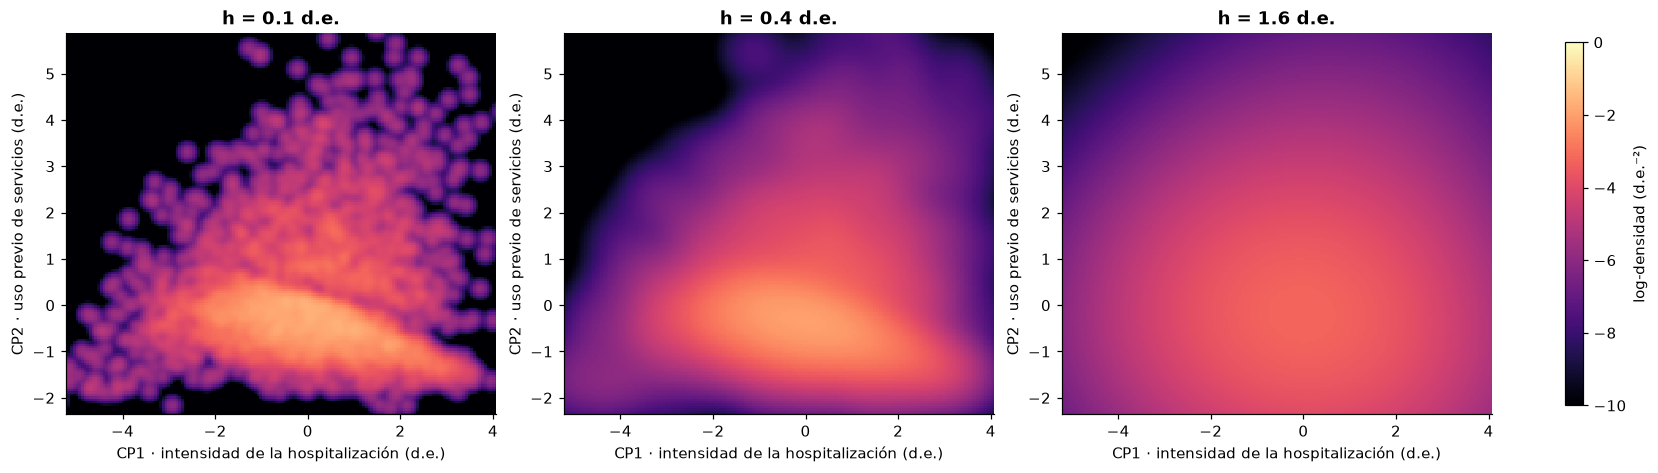

Masa total en la ventana: 0.996. Región de mayor densidad que contiene el 50 % de la masa: 7.1% del área de la ventana.


In [9]:
gx, gy, xx, yy, G = grid()
fig, axes = plt.subplots(1, 3, figsize=(15, 4.8), layout='constrained')
for ax, h in zip(axes, [.1, best_h, 1.6]):
    ld = KernelDensity(bandwidth=h).fit(X).score_samples(G).reshape(xx.shape)
    mesh = ax.pcolormesh(xx, yy, ld, shading='auto', cmap='magma', vmin=-10, vmax=0)
    plane_axes(ax, f'h = {h:g} d.e.')
fig.colorbar(mesh, ax=list(axes), label='log-densidad (d.e.⁻²)', shrink=.7); plt.show()

dens = np.exp(kde.score_samples(G)).reshape(xx.shape)
dx, dy = gx[1] - gx[0], gy[1] - gy[0]
order = np.sort(dens.ravel())[::-1]; cum = np.cumsum(order) * dx * dy
level50 = order[np.searchsorted(cum, .5)]
print(f'Masa total en la ventana: {cum[-1]:.3f}. Región de mayor densidad que contiene el 50 % de la masa: '
      f'{(dens >= level50).mean():.1%} del área de la ventana.')

### 3.3 Masa en una región fija

In [10]:
def kde_mass(x0, x1, y0, y1, n=200):
    rx, ry = np.linspace(x0, x1, n), np.linspace(y0, y1, n); rxx, ryy = np.meshgrid(rx, ry)
    v = np.exp(kde.score_samples(np.c_[rxx.ravel(), ryy.ravel()])).reshape(rxx.shape)
    return trapezoid(trapezoid(v, rx, axis=1), ry)
region = (-1, 1, -1, 1)
m = kde_mass(*region)
emp = np.mean((X[:, 0] >= -1) & (X[:, 0] <= 1) & (X[:, 1] >= -1) & (X[:, 1] <= 1))
print(f'Masa KDE en CP1∈[-1,1] × CP2∈[-1,1]: {m:.3f} | fracción empírica de pacientes: {emp:.3f}')

Masa KDE en CP1∈[-1,1] × CP2∈[-1,1]: 0.351 | fracción empírica de pacientes: 0.390


### Para resolver
Ticket: explique por qué densidad puntual, masa en una región y número de camas/enfermeras de seguimiento son tres cantidades diferentes.

**Nuestra respuesta y evidencia:**


- **Densidad puntual** (d.e.⁻²): altura de la superficie en un punto del plano; puede superar 1 y no es una proporción.
- **Masa en una región**: integral de la densidad; es una proporción de pacientes. En CP1, CP2 ∈ [−1, 1] la KDE da **0.351** y la fracción
  empírica es 0.390 (la KDE reparte parte de la masa fuera del cuadrado por el suavizado).
- **Recursos de seguimiento** (enfermeras, llamadas, camas): dependen del *número absoluto* de pacientes (volumen del hospital, que la muestra no
  conoce), de cuántos requieren intervención (riesgo, que la densidad no mide) y de la capacidad y costo por paciente. Una zona densa puede tener
  riesgo bajo, y una zona poco densa, riesgo alto.

## 4. DBSCAN · Zonas conectadas y puntos aislados (Sesión 3)
$N_\varepsilon(x_i)=\{x_j:\|x_i-x_j\|\le\varepsilon\}$; núcleo si $|N_\varepsilon(x_i)|\ge m$ contándose a sí mismo.

### Para resolver
En una línea: A=0, B=0.1, C=0.2, D=0.3, E=0.8. eps=0.115, min_samples=3.

In [11]:
tiny = np.c_[[0, .1, .2, .3, .8], np.zeros(5)]
manual = DBSCAN(eps=.115, min_samples=3).fit(tiny)
nbrs = NearestNeighbors(radius=.115).fit(tiny).radius_neighbors(tiny, return_distance=False)
print('Vecinos:', {'ABCDE'[i]: ['ABCDE'[j] for j in sorted(v)] for i, v in enumerate(nbrs)})
print('Núcleos:', ['ABCDE'[i] for i in manual.core_sample_indices_], '| etiquetas:', manual.labels_)

Vecinos: {'A': ['A', 'B'], 'B': ['A', 'B', 'C'], 'C': ['B', 'C', 'D'], 'D': ['C', 'D'], 'E': ['E']}
Núcleos: ['B', 'C'] | etiquetas: [ 0  0  0  0 -1]


**Nuestra respuesta y evidencia:**


Vecinos con eps = 0.115 (incluyéndose): A={A,B}, B={A,B,C}, C={B,C,D}, D={C,D}, E={E}.
**Núcleos:** B y C (3 vecinos ≥ m = 3). **Fronteras:** A y D (alcanzables desde un núcleo, pero con solo 2 vecinos no expanden).
**Ruido:** E (0.5 de distancia al más cercano). Resultado: un grupo {A,B,C,D} y E como ruido. El diámetro del grupo (0.3) **supera** eps:
la conectividad encadena núcleos.

### 4.1 Distancia al m-ésimo vecino y tabla de sensibilidad (desarrollo)
La tabla reporta, para cada configuración, **número de grupos, cobertura** (fracción de puntos que no son ruido), el tamaño del mayor grupo
y del segundo, y la **silhouette**. Importante: la silhouette **excluye el ruido** y se calcula sobre una **submuestra fija de 1 000 puntos**
(semilla 42) de los no-ruido, porque su costo es cuadrático; no es la silhouette de los 6 000 pacientes. Cuando hay menos de 2 grupos no está definida (NaN).

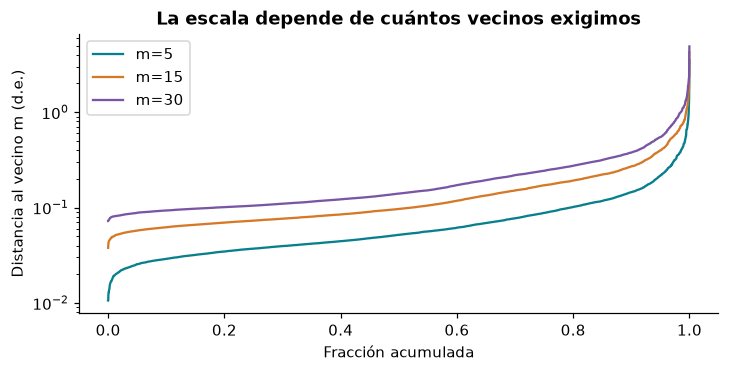

,eps,min_samples,n_clusters,coverage,largest_share,second_cluster,silhouette_1000
0,0.1,5,58,0.860,0.704,410,-0.270
1,0.1,15,8,0.612,0.585,35,-0.182
2,0.1,30,7,0.365,0.324,74,-0.225
3,0.2,5,11,0.960,0.947,17,0.266
4,0.2,15,7,0.885,0.860,65,0.020
5,0.2,30,4,0.754,0.701,188,0.091
6,0.3,5,7,0.982,0.975,11,0.285
7,0.3,15,2,0.947,0.944,18,0.452
8,0.3,30,1,0.900,0.900,0,NaN
9,0.4,5,1,0.991,0.991,0,NaN


In [12]:
fig, ax = plt.subplots(figsize=(7.5, 3.3))
for m in [5, 15, 30]:
    d_, _ = NearestNeighbors(n_neighbors=m).fit(X).kneighbors(X)
    kth = np.sort(d_[:, m - 1]); ax.plot(np.arange(len(kth)) / len(kth), kth, label=f'm={m}')
ax.set(xlabel='Fracción acumulada', ylabel='Distancia al vecino m (d.e.)', yscale='log',
       title='La escala depende de cuántos vecinos exigimos'); ax.legend(); plt.show()

rows = []
for eps in [.1, .2, .3, .4, .6, .8]:
    for m in [5, 15, 30]:
        lab = DBSCAN(eps=eps, min_samples=m).fit_predict(X)
        sizes = pd.Series(lab[lab != -1]).value_counts()
        rows.append(dict(eps=eps, min_samples=m, n_clusters=len(sizes), coverage=np.mean(lab != -1),
                         largest_share=(sizes.max() / len(X)) if len(sizes) else 0,
                         second_cluster=int(sizes.iloc[1]) if len(sizes) > 1 else 0,
                         silhouette_1000=safe_silhouette(X, lab)))
db_sens = pd.DataFrame(rows); display(db_sens.round(3))

### Para resolver
Seleccione una configuración con un argumento de escala y otro de sensibilidad. ¿Por qué no basta ordenar por silhouette?

**Nuestra respuesta y evidencia:**


**Configuración elegida: eps = 0.3 d.e., min_samples = 15.**
- *Argumento de escala:* en la curva m = 15, el 90 % de los pacientes tiene su 15.º vecino a menos de 0.27 d.e. y el 95 % a menos de 0.40;
  con eps = 0.3 el 92 % de los puntos es núcleo potencial, así que el "ruido" es la cola realmente dispersa y no la mitad de los datos.
- *Argumento de sensibilidad:* con m = 15, eps = 0.2 → 7 grupos (cobertura 88.5 %), eps = 0.3 → 2 grupos (94.7 %), eps ≥ 0.4 → 1 grupo.
  La estructura es **una gran masa conectada** más fragmentos; esa conclusión permanece en todo el rango, lo que cambia es cuántos fragmentos se separan.
  Con la mitad de la muestra y m fijo se obtienen 2 grupos (ruido 9.1 %); con m/2, 3 grupos (ruido 4.9 %): reducir m conserva aproximadamente el umbral de conteo, no la misma partición.
- **Por qué no ordenar por silhouette:** el máximo (0.452, estimado sobre una submuestra fija de 1 000 puntos no-ruido, no sobre los 6 000) lo da eps = 0.3/m = 15 porque compara una masa de 5 666 puntos con un fragmento de 18,
  y la silhouette excluye el ruido; con 1 grupo no está definida (NaN) y con muchos fragmentos es negativa. Premia separaciones triviales,
  ignora la cobertura y no dice nada sobre si los grupos son útiles.

### 4.2 Figura 3 · DBSCAN con tres eps (mismos ejes) y prueba de media muestra

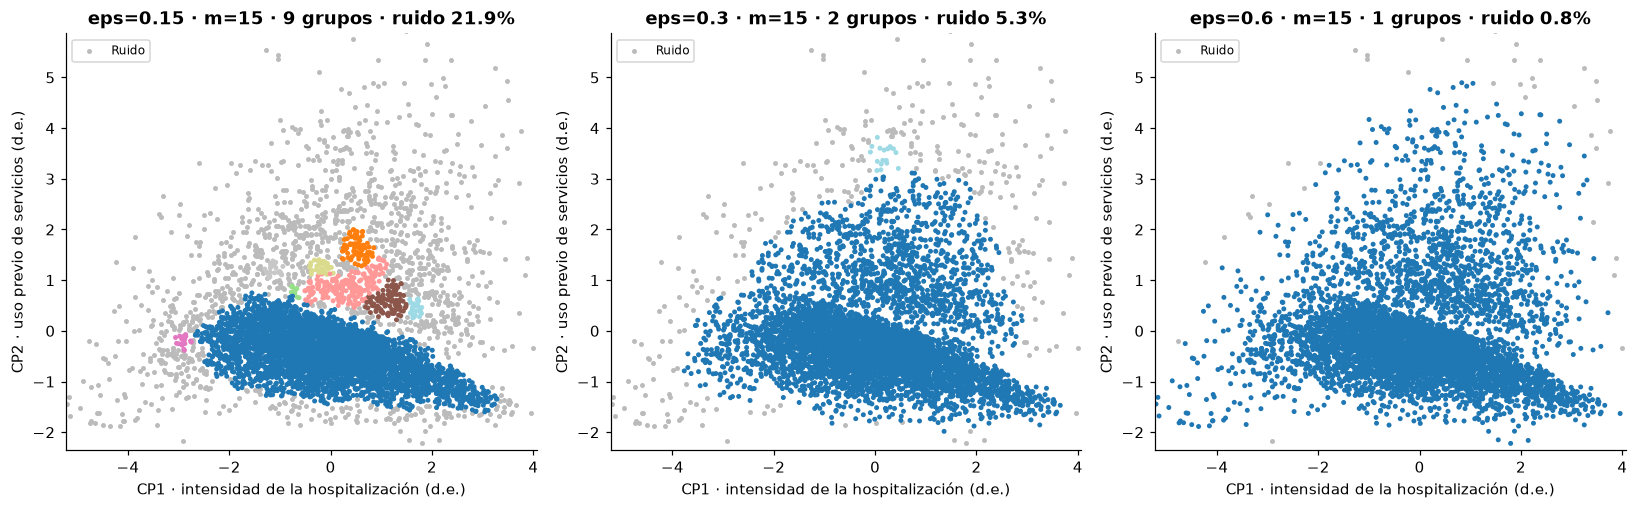

Completa         grupos=2  ruido=0.053
Mitad, m fijo    grupos=2  ruido=0.091
Mitad, m/2       grupos=3  ruido=0.049


In [13]:
CHOSEN_EPS, CHOSEN_M = 0.3, 15   # fijados con la tabla anterior (ver respuesta)
fig, axes = plt.subplots(1, 3, figsize=(15, 4.8))
for ax, eps in zip(axes, [CHOSEN_EPS / 2, CHOSEN_EPS, CHOSEN_EPS * 2]):
    lab = DBSCAN(eps=eps, min_samples=CHOSEN_M).fit_predict(X)
    ax.scatter(*X[lab == -1].T, s=5, color='#bbbbbb', label='Ruido')
    ax.scatter(*X[lab != -1].T, c=lab[lab != -1] % 20, cmap='tab20', s=5)
    plane_axes(ax, f'eps={eps:g} · m={CHOSEN_M} · {len(set(lab)) - (-1 in lab)} grupos · ruido {np.mean(lab == -1):.1%}')
    ax.legend(fontsize=8, loc='upper left')
fig.tight_layout(); plt.show()

db_labels = DBSCAN(eps=CHOSEN_EPS, min_samples=CHOSEN_M).fit_predict(X)
half = np.random.default_rng(SEED).choice(len(X), len(X) // 2, replace=False)
for name, pts, m in [('Completa', X, CHOSEN_M), ('Mitad, m fijo', X[half], CHOSEN_M), ('Mitad, m/2', X[half], max(2, CHOSEN_M // 2))]:
    lab = DBSCAN(eps=CHOSEN_EPS, min_samples=m).fit_predict(pts)
    print(f'{name:<16} grupos={len(set(lab) - {-1})}  ruido={np.mean(lab == -1):.3f}')

## 5. Refuerzo · K-means y jerárquico en los mismos 500 puntos
### Para resolver
K-means con datos 0, 1, 4, 5 y centros iniciales 0 y 4. Ward con A={0,2}, B={5}.

K-means manual → centros [0.5 4.5] inercia 1.0
Ward manual → altura SciPy 4.6188 = sqrt(2·Δ) con Δ = 10.6667


,k,inertia,silhouette
0,1,20131.284,NaN
1,2,12268.653,0.377
2,3,7866.907,0.425
3,4,5961.611,0.373
4,5,5118.459,0.367
5,6,4327.876,0.335
6,7,3633.499,0.360
7,8,3231.343,0.349


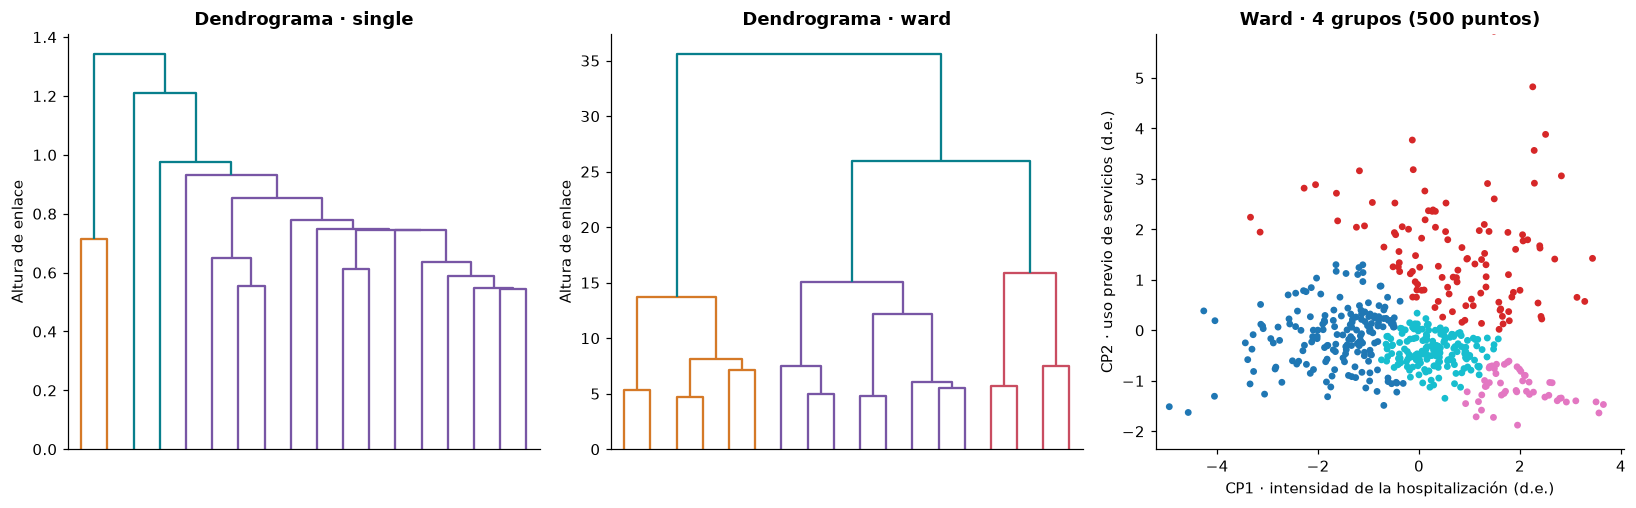

Mismos 500 puntos → silhouette K-means(4): 0.364 | Ward(4): 0.335


In [14]:
toy = KMeans(2, init=np.array([[0.], [4.]]), n_init=1).fit(np.array([0., 1., 4., 5.])[:, None])
print('K-means manual → centros', toy.cluster_centers_.ravel(), 'inercia', toy.inertia_)
ward_toy = linkage(np.array([0., 2., 5.])[:, None], method='ward')
print('Ward manual → altura SciPy', ward_toy[-1, 2].round(4), '= sqrt(2·Δ) con Δ =', (ward_toy[-1, 2] ** 2 / 2).round(4))

rows = []
for k in range(1, 9):
    km = KMeans(k, n_init=10, random_state=SEED).fit(X)
    rows.append(dict(k=k, inertia=km.inertia_, silhouette=safe_silhouette(X, km.labels_)))
km_tab = pd.DataFrame(rows); display(km_tab.round(3))

small_idx = np.random.default_rng(SEED).choice(len(X), 500, replace=False); Z = X[small_idx]
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, method in zip(axes[:2], ['single', 'ward']):
    dendrogram(linkage(Z, method=method), truncate_mode='lastp', p=18, ax=ax, no_labels=True)
    ax.set(title=f'Dendrograma · {method}', ylabel='Altura de enlace')
tree = linkage(Z, method='ward')
ward4, km4 = fcluster(tree, t=4, criterion='maxclust'), KMeans(4, n_init=10, random_state=SEED).fit_predict(Z)
axes[2].scatter(*Z.T, c=ward4, cmap='tab10', s=12); plane_axes(axes[2], 'Ward · 4 grupos (500 puntos)')
fig.tight_layout(); plt.show()
print('Mismos 500 puntos → silhouette K-means(4):', round(safe_silhouette(Z, km4), 3), '| Ward(4):', round(safe_silhouette(Z, ward4), 3))

**Nuestra respuesta y evidencia:**


- **K-means manual:** asignación {0,1}→0 y {4,5}→4; nuevas medias 0.5 y 4.5; inercia $4\times0.5^2=$ **1.0**.
- **Ward manual:** $\Delta=\frac{2\cdot1}{3}(1-5)^2=\frac{32}{3}=10.67$; SciPy muestra $\sqrt{2\Delta}=4.62$.
- **K-means en diabetes:** la inercia baja siempre con K (20 131 → 3 231); la silhouette (sobre la submuestra fija de 1 000 puntos) es máxima en K = 3 (0.425) y no muestra un codo claro.
  K-means asigna **todos** los pacientes, incluso los aislados, y sus centros no son "pacientes tipo" que convenga tratar igual.
- **Jerárquico (500 puntos):** el enlace simple **encadena** (fusiona por el par más cercano, así que la masa densa absorbe todo poco a poco);
  Ward produce grupos compactos. En la misma submuestra, silhouette K-means(4) = 0.364 vs. Ward(4) = 0.335 — comparables entre sí, pero **no** con la
  silhouette de 6 000 puntos (otra muestra, otro tamaño). Ward exige distancia euclídea; en este plano en d.e. es válida.

## 6. Evidencia comparada
### 6.1 Los tres mapas, mismos ejes

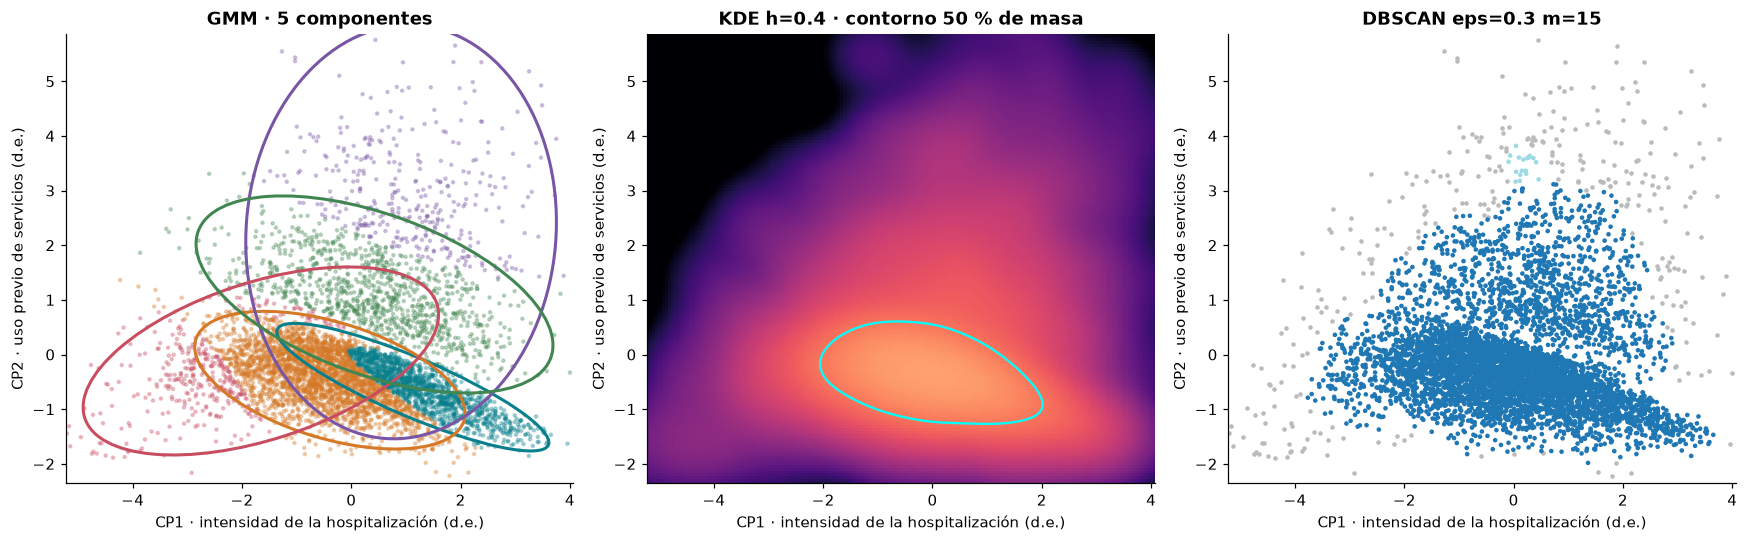

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
axes[0].scatter(*X.T, c=np.asarray(COLORS)[best.predict(X) % 8], s=4, alpha=.3); ellipses(axes[0], best)
plane_axes(axes[0], f'GMM · {int(winner.k)} componentes')
axes[1].pcolormesh(xx, yy, np.log(dens + 1e-12), shading='auto', cmap='magma', vmin=-10, vmax=0)
axes[1].contour(xx, yy, dens, levels=[level50], colors='cyan', linewidths=1.5); plane_axes(axes[1], f'KDE h={best_h} · contorno 50 % de masa')
axes[2].scatter(*X[db_labels == -1].T, s=4, color='#bbbbbb')
axes[2].scatter(*X[db_labels != -1].T, c=db_labels[db_labels != -1] % 20, cmap='tab20', s=4)
plane_axes(axes[2], f'DBSCAN eps={CHOSEN_EPS} m={CHOSEN_M}')
fig.tight_layout(); plt.show()

### 6.2 Zonas candidatas descritas por rangos
Cada zona se define por **rangos del plano** (percentiles 5–95 de sus pacientes) y se traduce a variables clínicas (medianas).
La tasa de readmisión < 30 días se calcula **después** de congelar los modelos: describe las zonas, no las eligió.

In [16]:
dev['gmm'] = best.predict(X); dev['dbscan'] = db_labels
dev['kde_logdens'] = kde.score_samples(X); dev['kde_top50'] = np.exp(dev.kde_logdens) >= level50
def describe(mask, name):
    sub = dev[mask]
    r = {'zona': name, 'n': len(sub), 'cobertura': len(sub) / len(dev),
         'CP1 (p5–p95)': f'[{sub.cp1.quantile(.05):.2f}, {sub.cp1.quantile(.95):.2f}]',
         'CP2 (p5–p95)': f'[{sub.cp2.quantile(.05):.2f}, {sub.cp2.quantile(.95):.2f}]'}
    r.update({c: sub[c].median() for c in FEATURES}); r['readm<30 (%)'] = 100 * sub.readm30.mean()
    return r
rows = [describe(dev.gmm == k, f'GMM comp. {k}') for k in range(int(winner.k))]
rows += [describe(dev.dbscan == g, f'DBSCAN grupo {g}') for g in pd.Series(db_labels[db_labels != -1]).value_counts().index[:4]]
rows += [describe(dev.dbscan == -1, 'DBSCAN ruido'), describe(dev.kde_top50, 'KDE región 50 % masa'),
         describe(~dev.kde_top50, 'KDE fuera de 50 %'), describe(dev.index == dev.index, 'Todos')]
zones = pd.DataFrame(rows).set_index('zona'); display(zones.round(2))

,n,cobertura,CP1 (p5–p95),CP2 (p5–p95),time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses,age_num,readm<30 (%)
zona,,,,,,,,,,,,,,
GMM comp. 0,1411,0.24,"[0.17, 2.82]","[-1.38, 0.00]",6.0,52.0,2.0,19.0,0.0,0.0,0.0,9.0,75.0,12.05
GMM comp. 1,2859,0.48,"[-1.98, 0.92]","[-1.29, 0.38]",3.0,41.0,1.0,12.0,0.0,0.0,0.0,6.0,65.0,7.76
GMM comp. 2,361,0.06,"[-0.76, 3.04]","[1.72, 4.98]",4.0,50.0,1.0,16.0,1.0,1.0,1.0,9.0,75.0,18.28
GMM comp. 3,378,0.06,"[-4.50, -0.77]","[-1.62, 0.84]",2.0,37.0,0.0,6.0,0.0,0.0,0.0,4.0,45.0,6.08
GMM comp. 4,991,0.17,"[-1.74, 2.43]","[0.13, 2.15]",4.0,44.0,1.0,15.0,0.0,0.0,0.0,8.0,75.0,12.31
DBSCAN grupo 0,5666,0.94,"[-2.19, 2.20]","[-1.26, 1.74]",4.0,44.0,1.0,14.0,0.0,0.0,0.0,7.0,65.0,9.65
DBSCAN grupo 1,18,0.00,"[-0.07, 0.42]","[3.17, 3.67]",2.0,42.5,0.5,13.0,2.0,1.0,1.0,9.0,60.0,16.67
DBSCAN ruido,316,0.05,"[-4.60, 3.39]","[-1.81, 5.22]",3.0,46.0,0.0,13.0,1.0,0.0,0.0,8.0,65.0,16.77
KDE región 50 % masa,3493,0.58,"[-1.59, 1.54]","[-1.05, 0.26]",4.0,43.0,1.0,14.0,0.0,0.0,0.0,7.0,65.0,9.28


### 6.3 Tabla de sensibilidad consolidada (un hiperparámetro por método)
La silhouette de DBSCAN se estima, como en 4.1, sobre una submuestra fija de 1 000 puntos no-ruido.

In [17]:
sens = []
for cov in ['full', 'diag']:
    w = gmm_sel[(gmm_sel.covariance == cov) & gmm_sel.converged].sort_values('bic').iloc[0]
    sens.append(dict(método='GMM', variación=f'covarianza={cov}', resultado=f'K por BIC = {int(w.k)}'))
for h in [.1, best_h, 1.6]:
    ld = KernelDensity(bandwidth=h).fit(X).score_samples(G).reshape(xx.shape)
    d_ = np.exp(ld); o = np.sort(d_.ravel())[::-1]; lv = o[np.searchsorted(np.cumsum(o) * dx * dy, .5)]
    from scipy import ndimage
    nreg = ndimage.label(d_ >= lv)[1]
    sens.append(dict(método='KDE', variación=f'h={h:g}', resultado=f'{nreg} región(es) conexas con 50 % de masa; área {(d_ >= lv).mean():.1%} de la ventana'))
for eps in [CHOSEN_EPS / 2, CHOSEN_EPS, CHOSEN_EPS * 2]:
    lab = DBSCAN(eps=eps, min_samples=CHOSEN_M).fit_predict(X)
    sens.append(dict(método='DBSCAN', variación=f'eps={eps:g}, m={CHOSEN_M}',
                     resultado=f'{len(set(lab) - {-1})} grupos, cobertura {np.mean(lab != -1):.1%}, silhouette (1 000 pts) {safe_silhouette(X, lab):.3f}'))
sens = pd.DataFrame(sens); display(sens)

,método,variación,resultado
0,GMM,covarianza=full,K por BIC = 5
1,GMM,covarianza=diag,K por BIC = 9
2,KDE,h=0.1,1 región(es) conexas con 50 % de masa; área 5....
3,KDE,h=0.4,1 región(es) conexas con 50 % de masa; área 7....
4,KDE,h=1.6,1 región(es) conexas con 50 % de masa; área 22...
5,DBSCAN,"eps=0.15, m=15","9 grupos, cobertura 78.1%, silhouette (1 000 p..."
6,DBSCAN,"eps=0.3, m=15","2 grupos, cobertura 94.7%, silhouette (1 000 p..."
7,DBSCAN,"eps=0.6, m=15","1 grupos, cobertura 99.2%, silhouette (1 000 p..."


### 6.4 Evidencia por método


| Método | Objeto estimado | Parámetros elegidos (con desarrollo) | Evidencia | Limitación |
|---|---|---|---|---|
| **GMM** | Densidad como mezcla de 5 gaussianas + responsabilidades | K = 5, covarianza completa, `reg_covar`=1e-5, n_init = 5 (mín. BIC en rejilla 1–10) | Las 5 componentes (sección 2.3): 1 = núcleo de ingresos moderados (48 %); 0 = ingresos largos y complejos sin uso previo (24 %); 4 = uso previo moderado, todos con ≥ 1 visita previa (17 %); 3 = ingresos breves de pacientes jóvenes (6 %); 2 = uso previo alto (6 %, la mayor readmisión) | Componentes ≠ perfiles reales; con diag el BIC elige 9; supone forma elíptica en datos de conteo |
| **KDE** | Superficie de densidad no paramétrica (d.e.⁻²) | Kernel gaussiano, h = 0.4 d.e. (validación temporal expansiva, 3 folds) | El 50 % de la masa ocupa solo el 7 % de la ventana: un único núcleo en CP1 ∈ [−2, 2], CP2 ∈ [−1.2, 0.6]; el abanico superior es una "pluma" continua de baja densidad | No define grupos ni asigna puntos; h controla qué estructura se ve (con h = 1.6 la región del 50 % ocupa el 22 % del área) |
| **DBSCAN** | Componentes conectadas de núcleos + ruido (transductivo) | eps = 0.3 d.e., min_samples = 15 | 2 grupos: una masa (94 %) y un fragmento de 18 pacientes en CP1 ∈ [−0.1, 0.4], CP2 ∈ [3.2, 3.7]; ruido 5.3 %, sobre todo en CP2 > 1 y en el extremo CP1 < −3 | Un solo eps no sirve para densidades tan distintas: con eps = 0.15 el abanico se parte en varias islas (9 grupos en total); con eps = 0.6 todo es un grupo |

**Región que KDE suaviza y DBSCAN conecta o separa.** La franja CP1 ∈ [−1, 2], CP2 ∈ [0.5, 2] (pacientes con 1–2 visitas previas):
la KDE la muestra como una **pendiente continua** que desciende desde el núcleo, sin frontera. DBSCAN con eps = 0.15 la **separa** en
7 islas pequeñas y la declara ruido en su mayoría; con eps = 0.3 la **conecta** a la masa principal. La KDE describe un gradiente; DBSCAN
obliga a decidir un umbral de conectividad. Ninguna de las dos lecturas es "la verdad": la franja es un continuo con densidad intermedia.


## 6.5 Extensión · Davies–Bouldin y estabilidad por remuestreo
La guía la propone para la semana siguiente; se adelanta aquí. **Davies–Bouldin** (menor es mejor) compara la dispersión de cada grupo con la
distancia a su grupo más parecido. La **estabilidad** se mide reajustando cada método en 20 remuestras bootstrap y comparando, con el
**índice de Rand ajustado (ARI)**, las etiquetas que la remuestra asigna a los 6 000 puntos con las de la solución original (1 = misma partición).
GMM y K-means asignan todos los puntos con `predict`; DBSCAN es transductivo, así que se compara solo sobre los puntos presentes en la remuestra.

In [18]:
from sklearn.metrics import davies_bouldin_score, adjusted_rand_score
km5 = KMeans(int(winner.k), n_init=10, random_state=SEED).fit(X)
ref = {'GMM (K=%d, full)' % int(winner.k): best.predict(X), 'K-means (K=%d)' % int(winner.k): km5.labels_,
       f'DBSCAN (eps={CHOSEN_EPS}, m={CHOSEN_M})': db_labels}
rng = np.random.default_rng(SEED); B = 20; stab = {k: [] for k in ref}
for b in range(B):
    ids = rng.choice(len(X), len(X), replace=True)
    g = GaussianMixture(int(winner.k), covariance_type=winner.covariance, n_init=2, max_iter=400,
                        reg_covar=1e-5, random_state=b).fit(X[ids])
    stab[list(ref)[0]].append(adjusted_rand_score(ref[list(ref)[0]], g.predict(X)))
    k_ = KMeans(int(winner.k), n_init=3, random_state=b).fit(X[ids])
    stab[list(ref)[1]].append(adjusted_rand_score(ref[list(ref)[1]], k_.predict(X)))
    u = np.unique(ids)
    stab[list(ref)[2]].append(adjusted_rand_score(db_labels[u], DBSCAN(eps=CHOSEN_EPS, min_samples=CHOSEN_M).fit_predict(X[u])))
rows = []
for name, lab in ref.items():
    m = lab != -1
    rows.append(dict(método=name, grupos=len(set(lab[m])), cobertura=m.mean(),
                     davies_bouldin=davies_bouldin_score(X[m], lab[m]) if len(set(lab[m])) > 1 else np.nan,
                     silhouette_1000=safe_silhouette(X, lab),
                     ARI_medio=np.mean(stab[name]), ARI_p10=np.percentile(stab[name], 10)))
ext = pd.DataFrame(rows); display(ext.round(3))

,método,grupos,cobertura,davies_bouldin,silhouette_1000,ARI_medio,ARI_p10
0,"GMM (K=5, full)",5,1.000,1.109,0.241,0.729,0.459
1,K-means (K=5),5,1.000,0.913,0.367,0.669,0.393
2,"DBSCAN (eps=0.3, m=15)",2,0.947,0.448,0.452,0.776,0.745


**Nuestra respuesta y evidencia:**


- **Davies–Bouldin:** DBSCAN obtiene el mejor valor (0.45), K-means 0.91 y GMM 1.11. Igual que con la silhouette, el valor de DBSCAN premia
  una separación trivial (una masa del 94 % frente a un fragmento de 18 pacientes) y se calcula sin el ruido; GMM sale peor porque sus componentes se
  **superponen a propósito** (es un modelo de densidad, no una partición), algo que un índice de separación penaliza.
- **Estabilidad (ARI en 20 remuestras bootstrap):** DBSCAN 0.78 (p10 = 0.75), GMM 0.73 (p10 = 0.46), K-means 0.67 (p10 = 0.39). La masa principal
  de DBSCAN es muy estable; las particiones en 5 de GMM y sobre todo de K-means cambian bastante entre remuestras (en el 10 % de los casos el ARI
  baja de 0.46 y 0.39): las fronteras que trazan dentro del continuo de pacientes **no son robustas**, lo que refuerza no presentarlas como perfiles reales.
- **Conclusión que permanece:** "un núcleo estable más un abanico de uso previo" sobrevive a los tres métodos y al remuestreo; los cortes finos
  dentro del núcleo, no. La dependencia entre pacientes del mismo hospital (análoga a la dependencia espacial) no se puede evaluar: el dataset no identifica el hospital.

## 7. Congelar, después evaluar en el periodo reservado
Configuraciones congeladas con desarrollo. Ahora se abre el test (último 30 % de pacientes en orden de `encounter_id`) una sola vez.

In [19]:
frozen = dict(gmm=dict(k=int(winner.k), covariance=winner.covariance), kde_h=best_h, dbscan=dict(eps=CHOSEN_EPS, m=CHOSEN_M), seed=SEED)
print('Congelado:', frozen)
test['gmm_logdens'] = best.score_samples(Xt); test['kde_logdens'] = kde.score_samples(Xt)
test['block'] = pd.qcut(np.arange(len(test)), 4, labels=['T1', 'T2', 'T3', 'T4'])
display(test.groupby('block', observed=True)[['gmm_logdens', 'kde_logdens']].mean().round(3))
print('Media de desarrollo (in-sample) · GMM', best.score_samples(X).mean().round(3), '| KDE', kde.score_samples(X).mean().round(3))

test['gmm'] = best.predict(Xt); test['kde_top50'] = np.exp(test.kde_logdens) >= level50
comp_share = pd.DataFrame({'desarrollo': dev.gmm.value_counts(normalize=True), 'test': test.gmm.value_counts(normalize=True)}).sort_index()
display(comp_share.round(3))
print(f'Fracción en región KDE 50 %: desarrollo {dev.kde_top50.mean():.3f} | test {test.kde_top50.mean():.3f}')
# DBSCAN es transductivo: se reajusta con la misma configuración sobre una muestra de test del mismo tamaño.
lt = DBSCAN(eps=CHOSEN_EPS, min_samples=CHOSEN_M).fit_predict(Xt[np.random.default_rng(SEED).choice(len(Xt), 6000, replace=False)])
print(f'DBSCAN reajustado en 6 000 de test: {len(set(lt) - {-1})} grupos, cobertura {np.mean(lt != -1):.3f}')

Congelado: {'gmm': {'k': 5, 'covariance': 'full'}, 'kde_h': 0.4, 'dbscan': {'eps': 0.3, 'm': 15}, 'seed': 42}


,gmm_logdens,kde_logdens
block,,
T1,-3.033,-3.125
T2,-2.928,-3.024
T3,-2.991,-3.081
T4,-3.043,-3.125


Media de desarrollo (in-sample) · GMM -2.991 | KDE -3.04


,desarrollo,test
gmm,,
0,0.235,0.288
1,0.476,0.398
2,0.060,0.077
3,0.063,0.040
4,0.165,0.196


Fracción en región KDE 50 %: desarrollo 0.582 | test 0.585
DBSCAN reajustado en 6 000 de test: 2 grupos, cobertura 0.949


**Nuestra respuesta y evidencia:**


- **Transferencia de la densidad:** la log-densidad media en los cuatro bloques del periodo reservado (GMM −2.93 a −3.04; KDE −3.02 a −3.13)
  está al nivel de desarrollo (GMM −2.99; KDE −3.04). No hay degradación temporal: la forma de la nube de pacientes es estable.
- **Proporciones:** la región KDE del 50 % contiene el 58.2 % de desarrollo y el 58.5 % de test. Las componentes GMM se desplazan algo
  (comp. 1: 47.6 % → 39.8 %; comp. 0: 23.5 % → 28.8 %): los pacientes recientes tienen ingresos algo más intensos.
- **DBSCAN** reajustado con la misma configuración en 6 000 pacientes de test: 2 grupos y cobertura 94.9 % (vs. 94.7 %).
- **Readmisión (descripción externa):** la tasa baja de 10.0 % en desarrollo a **7.2 %** en test. Probablemente es un efecto de la ventana
  de observación (los primeros ingresos más recientes tienen menos tiempo para que se registre un reingreso), no una mejora clínica.
  En términos *relativos* se mantiene el orden: la componente 2 tiene la mayor tasa en ambos periodos (18.3 % y 11.8 %, ≈1.6–1.8 veces la base)
  y la región CP2 ≥ 3 también (26.4 % y 12.9 %).

## 8. Tickets individuales

**Nuestra respuesta y evidencia:**


**Lunes (GMM).** 1) EM maximiza la log-verosimilitud de la mezcla; cada iteración no la empeora, pero puede quedar en un máximo local.
2) r = 0.55 significa que el 55 % de la densidad del modelo en ese punto proviene de esa componente; es incertidumbre de asignación dentro del modelo,
no la probabilidad de que el paciente "sea" de un perfil real. 3) El BIC no demuestra un número verdadero de grupos, ni que los datos sean gaussianos,
ni que las componentes tengan significado clínico; solo ordena candidatos sobre las mismas observaciones.

**Miércoles (KDE).** Densidad puntual (d.e.⁻², altura), masa regional (proporción de pacientes en un área, integral) y cantidad de recursos
(enfermeras, llamadas: dependen del volumen absoluto, del riesgo y de la capacidad) son objetos distintos; ninguno se deduce del otro sin información adicional.

**Viernes (DBSCAN).** ¿El diámetro puede superar eps? **Sí**: en el ejercicio manual el grupo mide 0.3 con eps = 0.115, y en diabetes la masa principal mide
más de 6 d.e. con eps = 0.3, porque los núcleos se encadenan. ¿Todo punto frontera une grupos? **No**: una frontera no expande; dos grupos solo se unen
por núcleos conectados (un punto frontera alcanzable desde dos grupos se asigna a uno, según el orden). ¿Ruido = error? **No**: el 5.3 % de ruido son
pacientes con combinaciones poco comunes (muchas visitas previas); su readmisión es más alta (16.8 % en desarrollo), justamente lo contrario de datos descartables.

## 9. Recomendación del comité

**Nuestra respuesta y evidencia:**


### Tres figuras interpretadas
1. **Figura 1 (GMM + entropía):** la entropía es máxima en la frontera entre la masa baja y el abanico (CP2 ≈ 0 a 0.5): ahí la asignación a perfiles es
   arbitraria; lejos de esa franja las componentes están bien definidas.
2. **Figura 2 (KDE, tres h):** con h = 0.1 la superficie se fragmenta en manchas por los valores enteros de los conteos; con h = 0.4 aparece un único
   núcleo más una pluma hacia arriba; con h = 1.6 todo es una loma. La conclusión "un núcleo dominante" permanece; el detalle del abanico cambia con h.
3. **Figura 3 (DBSCAN, tres eps):** el número de grupos pasa de 9 a 2 a 1 al duplicar eps. La masa principal sobrevive siempre; los grupos del abanico
   no son estables ante eps.

### Recomendación (Observo → interpreto → recomendaría estudiar → vigilaría → no puedo concluir)

> **Observo** que los tres métodos coinciden en un núcleo denso de pacientes sin uso previo de servicios (CP1 ∈ [−2, 2], CP2 ∈ [−1.2, 0.6] d.e.; 58 % de
> los pacientes en ambos periodos) y un abanico disperso de pacientes con visitas previas (CP2 > 1), que GMM modela con dos componentes, la KDE como
> una pluma de baja densidad y DBSCAN como ruido o fragmentos inestables. **Interpreto** que el eje de uso previo, no la intensidad del ingreso, separa
> a los pacientes con más readmisión (zona CP2 ≥ 1: 1.4 veces la base en desarrollo y 1.2 en test; componente 2 del GMM: 1.6–1.8 veces), aunque densidad no es riesgo. **Recomendaría estudiar**
> (A) la zona CP2 ≥ 1 d.e. (≥ 1–2 visitas o ingresos previos; 15–19 % de los pacientes), y (B) la franja de ingresos intensos sin uso previo
> CP1 ∈ [0.2, 2.8], CP2 ∈ [−1.4, 0] (≈6 días, 19 medicamentos, 9 diagnósticos; 30 % de los pacientes), por volumen y carga, no por riesgo, que ahí está
> cerca de la base. **Vigilaría** la región CP2 ≥ 3 d.e. (≈3 % de los pacientes; 26 % y 13 % de readmisión), que DBSCAN marca como ruido o como un
> fragmento de 18 pacientes que desaparece al variar eps: requiere revisión caso a caso, no un protocolo de grupo. **No puedo concluir** cuántos
> "perfiles verdaderos" existen, ni que intervenir en estas zonas reduzca readmisiones, ni cuántos recursos se necesitan: faltan costos, capacidad,
> desenlaces tras el alta y una ventana de seguimiento comparable entre periodos.

### Guion de defensa (90 s)
- **20 s · Pregunta y datos:** 69 970 pacientes (primer ingreso), plano CP1 = intensidad del ingreso, CP2 = uso previo, ambos en d.e.; desarrollo = primer 70 %
  por orden de ingreso, test = último 30 %, abierto una vez.
- **40 s · Evidencia comparada:** GMM (K = 5 por BIC, no "5 perfiles"), KDE (h = 0.4 por validación temporal; 50 % de la masa en el 7 % del área),
  DBSCAN (eps = 0.3, m = 15; 2 grupos, 5 % ruido; pasa de 9 a 1 grupo al variar eps). Coinciden en núcleo + abanico; difieren en cómo tratan el abanico.
- **30 s · Recomendación y límites:** estudiar A (uso previo) y B (ingresos intensos), revisar CP2 ≥ 3; densidad ≠ riesgo ≠ recursos; la readmisión
  del test es más baja por la ventana de observación, así que solo comparamos tasas relativas.

## Fuentes y reproducción
- Guía `semana-08.html` y cuadernos de `semana-08-estudiantes (2)/notebooks/semana-08/` (estructura, utilidades y ejercicios manuales).
- Strack et al. (2014), *Impact of HbA1c measurement on hospital readmission rates*, BioMed Research International — fuente del dataset.
- scikit-learn: [GMM](https://scikit-learn.org/stable/modules/mixture.html), [KDE](https://scikit-learn.org/stable/modules/density.html), [clustering](https://scikit-learn.org/stable/modules/clustering.html).
- Semilla 42 en todo el cuaderno; se ejecuta desde la raíz del repositorio (donde está `diabetic_data.csv`).